In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

# First 5 rows display cheyyi
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [3]:
# Check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [4]:
# Remove missing values
df = df.dropna()

# Check again
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
# Convert Order Date into Date format

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check duplicate rows

df.duplicated().sum()

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [6]:
# Convert Order Date properly

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

# Check duplicates

df.duplicated().sum()

np.int64(0)

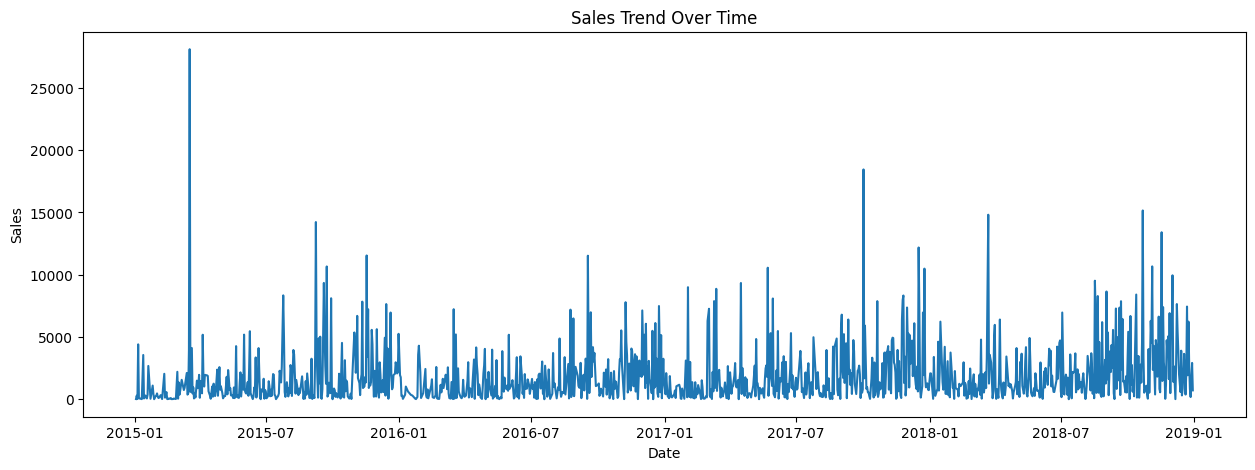

In [7]:
import matplotlib.pyplot as plt

# Group sales by Order Date
sales_trend = df.groupby("Order Date")["Sales"].sum()

# Plot graph
plt.figure(figsize=(15,5))

plt.plot(sales_trend)

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [8]:
# Monthly sales

monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

print("Highest Sales Month :", monthly_sales.idxmax())

print("Lowest Sales Month :", monthly_sales.idxmin())

monthly_sales

Highest Sales Month : 11
Lowest Sales Month : 2


,Sales
Order Date,
1,91982.1396
2,59371.1154
3,197573.5872
4,134988.2506
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


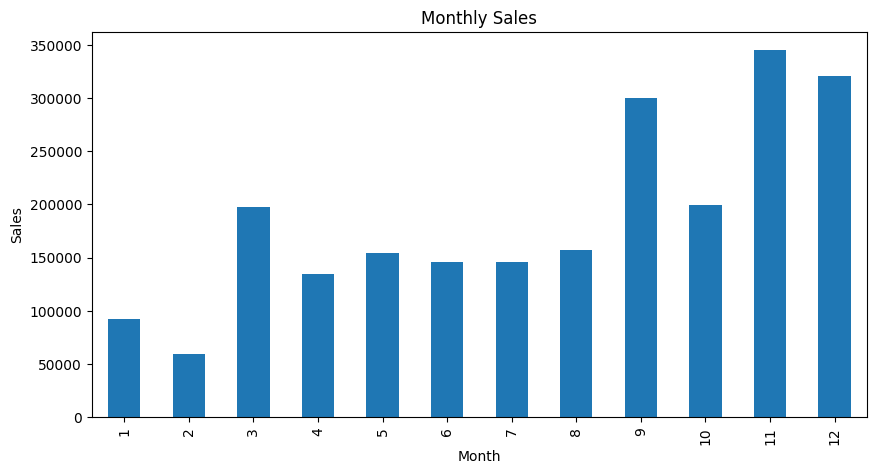

In [9]:
# Monthly Sales Bar Chart

monthly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [10]:
# Create Year, Month and Day columns

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Day"] = df["Order Date"].dt.day

# Check new columns

df[["Order Date","Year","Month","Day"]].head()

,Order Date,Year,Month,Day
0,2017-11-08,2017,11,8
1,2017-11-08,2017,11,8
2,2017-06-12,2017,6,12
3,2016-10-11,2016,10,11
4,2016-10-11,2016,10,11


In [11]:
from sklearn.model_selection import train_test_split

# Features
X = df[["Year", "Month", "Day"]]

# Target
y = df["Sales"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7831, 3)
(1958, 3)


In [12]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
# Predict sales

pred = model.predict(X_test)

# Compare actual vs predicted

comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": pred

})

comparison.head()

,Actual,Predicted
8962,273.960,220.560398
7138,62.880,236.774823
4709,11.680,219.845221
6204,7.712,211.194241
6901,2399.960,218.227006


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# MAE
mae = mean_absolute_error(y_test, pred)

# RMSE
rmse = root_mean_squared_error(y_test, pred)

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 286.1046315437984
RMSE : 700.0992649736078


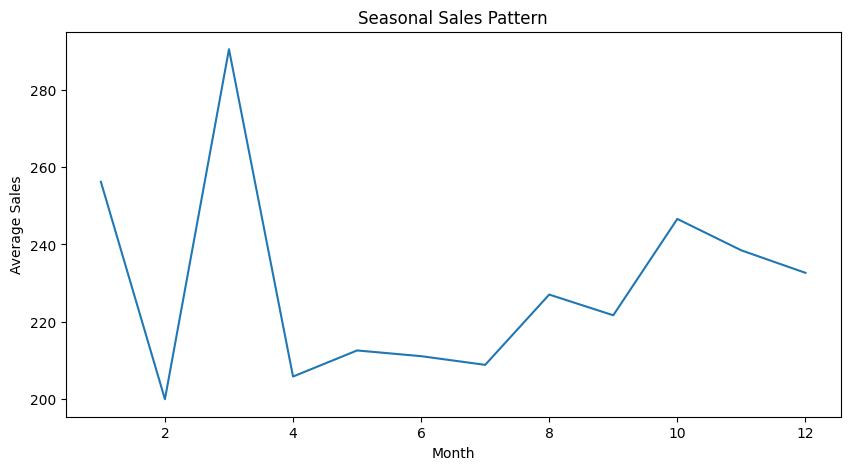

In [15]:
# Seasonal Pattern

seasonal_sales = df.groupby("Month")["Sales"].mean()

seasonal_sales.plot(kind="line", figsize=(10,5))

plt.title("Seasonal Sales Pattern")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.show()